### 머신러닝
지도학습

In [ ]:
# 선형회귀 : 숫자 예측 학습 모델
import numpy as np
import matplotlib.pyplot as plt

# 학습 모델 import -> 선형 회귀
from sklearn.linear_model import LinearRegression
# 평가지표 함수
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(display='text')
# 데이터 준비 : 특성 / 타깃 => 8 : 2
# 학습 데이터는 2차원 형식으로 변경해주어야한다.
X = np.array([1,2,3,4,5]).reshape(-1,1)
# 출력 데이터 : 라벨 (타깃)
y = np.array([50, 55, 65, 70, 75])
# 학습모델 생성(객체) => 학습
model = LinearRegression()

# 훈련
model.fit(X, y)

# 학습된 모델을 이용해서 값을 예측 : y, predict(X)
y_pred = model.predict(X)
print(y_pred)
print(([50, 55, 65, 70, 75]))

# 성능 지표
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mse)

print('mse : ', mse)
print('mae : ', mae)
print('rmse : ', rmse)
print('r2 : ', r2)

plt.scatter(X,y)
plt.plot(X, y_pred, c='r')
plt.show()

LinearRegression()

In [2]:
# 학습 결과 => 기울기(가중치), 절편
m = model.coef_[0]      # 기울기
b = model.intercept_    # 절편
print(m)
print(b)

6.500000000000001
43.5


In [4]:
# 학습된 모델을 이용해서 값을 예측 : y, predict(X)
y_pred = model.predict(X)
print(y_pred)
print(([50, 55, 65, 70, 75]))

[50.  56.5 63.  69.5 76. ]
[50, 55, 65, 70, 75]


In [6]:
# 성능 지표
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mse)

print('mse : ', mse)
print('mae : ', mae)
print('rmse : ', rmse)
print('r2 : ', r2)

mse :  1.5
mae :  1.0
rmse :  1.224744871391589
r2 :  0.9825581395348837


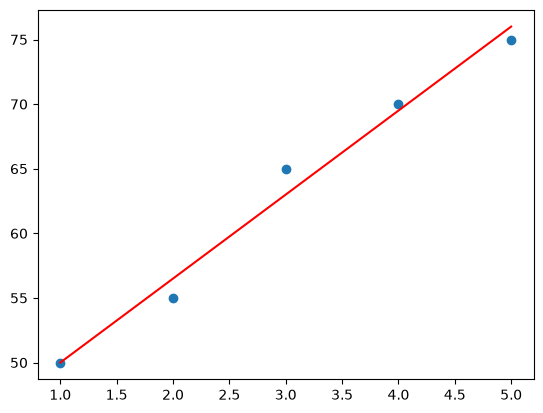

In [10]:
plt.scatter(X,y)
plt.plot(X, y_pred, c='r')
plt.show()

In [11]:
# 예측 : 6,8,10
new_hour = np.array([6,8,10]).reshape(-1,1)
predict_score = model.predict(new_hour)
print(predict_score)

[ 82.5  95.5 108.5]


=== 데이터첫 5행 ===
        Size         Price
0  24.981605  36495.505246
1  48.028572  54927.264367
2  39.279758  48663.076351
3  33.946339  37891.681719
4  16.240746  28145.618112

Size와 Price 간의 상관계수: 0.9632


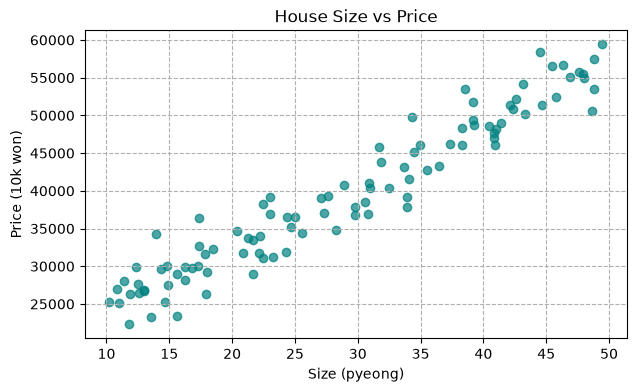

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 1. 재현성을위한 난수 시드 설정
np.random.seed(42)
# 2. 데이터생성: 평수(Size) 10~50평, 총 100세대
size = np.random.uniform(10, 50, 100)
# 주택 가격(Price): 기본 15000 + 평당 850 + 노이즈
price = 15000 + 850 * size + np.random.normal(0, 3000, 100)
df_house = pd.DataFrame({'Size': size, 'Price': price})
print("=== 데이터첫 5행 ===")
print(df_house.head())
# 3. EDA: 산점도와변수 간 상관계수구하기
correlation = df_house['Size'].corr(df_house['Price'])
print(f"\nSize와 Price 간의 상관계수: {correlation:.4f}")
plt.figure(figsize=(7, 4))
plt.scatter(df_house['Size'], df_house['Price'], color='teal', alpha=0.7)
plt.title('House Size vs Price')
plt.xlabel('Size (pyeong)')
plt.ylabel('Price (10k won)')
plt.grid(True, linestyle='--')
plt.show()

In [21]:
# 선형회귀 : 숫자 예측 학습 모델
import numpy as np
import matplotlib.pyplot as plt
# 데이터 분리 => 8 : 2
from sklearn.model_selection import train_test_split
# 학습 모델 import -> 선형 회귀
from sklearn.linear_model import LinearRegression
# 평가지표 함수
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(display='text')

# 특성(X)과 타겟(y) 설정 (Scikit-learn 입력 규격: X는 2차원 DataFrame, y는 1차원 Series)
X = df_house[['Size']]
y = df_house['Price']

# 훈련 데이터와 테스트 데이터의 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

model = LinearRegression()

model.fit(X_train, y_train)

# 테스트 데이터를 이용해서 예측값
y_pred = model.predict(X_test) # y_test

# 평가지표
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print('mse : ', mse)
print('mae : ', mae)
print('rmse : ', rmse)
print('r2 : ', r2)

(80, 1) (80,)
(20, 1) (20,)
mse :  5883295.623453015
mae :  1774.0277337569337
rmse :  2425.550581507839
r2 :  0.9446078584352587
